# 10 - Quality-first cohorts v2, from 25k to 1M ECGs

The v2 cohorts are nested, manifest-only pretraining sets of 25k, 50k, 100k, 150k, 200k, 500k and 1M ECGs,
built by `scripts/data/build_clean_cohorts_v2.py` (library `ecg_experiment/clean_cohorts_v2.py`). They follow
the user's decisions of 28-29 September 2026: fill from the curated human-read 500 Hz sources first (PTB-XL
training rows, Ningbo, Chapman, Georgia, CPSC 2018, CPSC-Extra), preferring records without review flags; add
CODE-15 from the 150k tier on; use MIMIC last; keep SPH out, because it is the external test hospital. CODE-15
and MIMIC are unlabeled SSL data only.

Every candidate is put in one seeded order and a tier is the first N rows of it, so each tier contains every
smaller one. This notebook describes what went into the order and what each tier contains. It reads the saved
order, the tier manifests and the source manifests; no waveform is read.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ecg_experiment.clean_cohorts_v2 import heldout_references
from ecg_experiment.eda import code15
from ecg_experiment.eda.signals import LEADS

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

WORK = ROOT / "outputs/data_quality/clean_cohorts_v2"
receipt = json.loads((WORK / "receipt.json").read_text())
text = dict.fromkeys(("patient_id", "index", "review_flags", "signal_sha256"), str)
order = pd.read_csv(WORK / "candidate_order.csv.gz", dtype=text, keep_default_na=False,
                    na_values={"age": [""], "male": [""]})
order["label_available"] = order["label_available"].astype(str) == "True"
sizes = sorted(receipt["tiers"].items(), key=lambda item: item[1]["records"])
tiers = {name: order.iloc[:item["records"]] for name, item in sizes}
print(f"{len(order):,} candidates; tiers written: {', '.join(tiers)}")

1,004,165 candidates; tiers written: 25k, 50k, 100k, 150k, 200k, 500k, 1m


## 1. Candidates

In [3]:
blocks = ["curated", "mimic_top_up", "code15", "mimic_local", "mimic_pending"]
display(pd.crosstab(order["source"], order["block"]).reindex(columns=blocks, fill_value=0)
        .assign(total=lambda frame: frame.sum(axis=1)))
display(pd.Series(receipt["projection"]).drop("pending_rows_per_tier").to_frame("value"))

block,curated,mimic_top_up,code15,mimic_local,mimic_pending,total
source,,,,,,
chapman_shaoxing,10208,0,0,0,0,10208
code15,0,0,127268,0,0,127268
cpsc_2018,6538,0,0,0,0,6538
cpsc_2018_extra,3002,0,0,0,0,3002
georgia,10177,0,0,0,0,10177
mimic,0,19625,0,176862,600035,796522
ningbo,33045,0,0,0,0,33045
ptbxl,17405,0,0,0,0,17405


,value
candidates,1004165
expected_candidates_after_scoring,993625
failure_rate,0.017565
pending_candidates,600035
tiers_expected_to_fill,"[25k, 50k, 100k, 150k, 200k, 500k]"


**Finding: 1,004,165 candidates, of which 600,035 are MIMIC records not yet downloaded.**

- **Curated sources:** 80,375 clean records — PTB-XL 17,405, Ningbo 33,045, Chapman 10,208, Georgia
  10,177, CPSC 2018 6,538 and CPSC-Extra 3,002.
  - This is 19,625 short of 100k, so the 100k tier is topped up with that many local MIMIC records, as the
    tier rule prescribes. CODE-15 therefore first enters at 150k.
- **CODE-15:** 127,268 usable exams.
- **MIMIC:** 196,487 clean downloaded records, and 600,035 pending records of 120,656 patients that have no
  downloaded record.
- **Removed as overlaps:** only 2 candidates. They are CODE-15 exams whose first 10 s repeat an earlier exam
  of the same patient. No candidate is a PTB-XL held-out record or patient, or a copy of any PTB-XL record.
- **Pending failures:** 1.76% of the downloaded MIMIC selection failed the audit or the policy. At that rate,
  about 10,500 pending records will fail, leaving 993,625 candidates.
  - The 1M tier can be listed today, but it is expected to fall about 6,400 records short once its pending
    rows are scored.
  - The tiers up to 500k are expected to fill.

## 2. CODE-15 after cleaning

`scripts/data/build_code15_clean.py` trims each exam's leading and trailing all-zero rows, keeps exams with at
least 10 s of signal, resamples them to 500 Hz and applies the quality policy
(`data/processed/code15_clean_v1/`).

In [4]:
clean15 = json.loads((ROOT / "data/processed/code15_clean_v1/metadata.json").read_text())
display(pd.Series(clean15["active_samples"]).rename("exams").to_frame().T)
display(pd.DataFrame(clean15["exclusion_reason_counts"]).fillna(0).astype(int))
display(pd.Series({
    "exams with 10 s of signal": clean15["ten_second_exams"]["exams"],
    "patients with such an exam": clean15["ten_second_exams"]["patients"],
    "excluded by the policy at either scale": clean15["excluded_ten_second_exams"],
    "exams usable for training": clean15["training"]["exams"],
    "patients with a usable exam": clean15["training"]["patients"],
}).to_frame("value"))
display(pd.Series(clean15["duplicate_status_ten_seconds"]).rename("10 s exams").to_frame().T)

,exactly_4096,ten_seconds_or_more,under_10s,zero
exams,130763,132161,212948,670


,either,halved,stored
adc_rail,16,1,16
constant_lead,733,733,733
extreme_amplitude,1241,6,1235
flat_segment,2138,2138,2138
near_flat_record,7,7,4
noise_dominated,1,1,1


,value
exams with 10 s of signal,132161
patients with such an exam,92246
excluded by the policy at either scale,3222
exams usable for training,127270
patients with a usable exam,90541


,dropped_conflict,dropped_copy,kept,unique
10 s exams,443,1344,1330,129044


,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6,median
source,,,,,,,,,,,,,
chapman_shaoxing,2.13,1.78,1.67,1.96,2.06,1.62,1.79,1.22,1.47,1.43,1.55,1.66,1.66
cpsc_2018,2.10,1.77,1.61,1.91,1.97,1.59,1.59,1.31,1.50,1.45,1.53,1.63,1.60
cpsc_2018_extra,1.97,1.89,1.60,1.97,1.79,1.69,1.62,1.19,1.44,1.50,1.61,1.65,1.63
georgia,1.83,1.75,1.49,1.81,1.67,1.61,1.78,1.66,2.03,2.11,2.10,2.06,1.80
mimic,1.80,2.00,1.44,2.02,1.51,1.73,1.97,1.75,2.06,2.16,2.28,2.25,1.98
ningbo,2.18,1.81,1.73,1.98,2.17,1.67,1.78,1.25,1.50,1.46,1.58,1.67,1.70
ptbxl,1.82,1.93,1.69,1.90,1.72,1.89,1.80,1.40,1.76,1.76,1.90,2.07,1.81


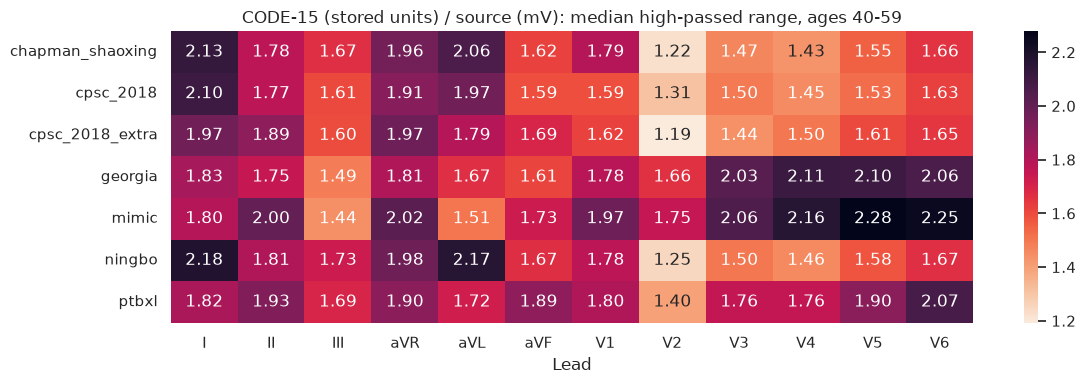

CODE-15 10 s exams aged 40-59: 38,082


In [5]:
exams = code15.load_exams()
ranges_path = ROOT / "outputs/data_quality/code15_clean_v1/amplitude_ranges.parquet"
ranges = pd.read_parquet(ranges_path).set_index("exam_id")
ranges.columns = [column.removeprefix("range_") for column in ranges.columns]
matched = ranges[exams.loc[ranges.index, "age"].between(40, 59).to_numpy()]
references = code15.amplitude_references().groupby(level="source").median()
ratio = (matched.median() / references)[LEADS]
display(ratio.round(2).assign(median=ratio.median(axis=1).round(2)))
fig, axis = plt.subplots(figsize=(12, 4))
sns.heatmap(ratio, annot=True, fmt=".2f", cmap="rocket_r", ax=axis)
axis.set(title="CODE-15 (stored units) / source (mV): median high-passed range, ages 40-59", xlabel="Lead",
         ylabel="")
plt.tight_layout()
plt.show()
print(f"CODE-15 10 s exams aged 40-59: {len(matched):,}")

**Finding: 132,161 CODE-15 exams have 10 s of signal; 127,270 are usable, and the amplitude unit
stays unresolved.**

- **Length:** after trimming the zero padding, 670 exams are empty and 212,948 are shorter than 10 s (mostly
  the 7.3 s recordings). 132,161 exams have at least 10 s: 130,763 fill all 4,096 samples (10.24 s) and 1,398
  have 4,000-4,095.
- **Quality:** the policy excludes 3,222 of the 10 s exams (2.4%). The main reasons are:
  - a lead flat for 1 s or more (2,138);
  - a constant lead (733);
  - an amplitude above 20 (1,241). 1,235 of these exceed 20 only when the stored values are read as mV and
    would pass if they were halved.
- **Duplicates:** among the 10 s exams, 1,344 are copies of another exam of the same patient and are dropped.
  443 are identical to an exam of a different patient, so every copy is dropped.
- **Usable:** 127,270 exams of 90,541 patients.
- **Amplitude:** with baseline wander removed, the median lead range of CODE-15 exams aged 40-59 is 1.60 to
  1.98 times that of each millivolt source (median over leads), and 1.19 to 2.28 times lead by lead.
  - The ratio is most uniform against the Western sources (PTB-XL 1.40-2.07, Georgia 1.49-2.11). The Chinese
    sources have larger precordial amplitudes, so V2-V4 give lower ratios against them.
  - The stored values are therefore about 1.6-2 times millivolts. That rules out both readings of the
    documentation: values in mV (a factor of 1) or in units of 0.1 mV (a factor of 10). It does not fix a
    single factor.

## 3. What each tier contains

In [6]:
composition = pd.DataFrame({name: rows["source"].value_counts() for name, rows in tiers.items()})
composition = composition.fillna(0).astype(int)
composition.loc["total"] = composition.sum()
display(composition)
display((composition.drop(index="total") / composition.loc["total"]).round(3))
display(pd.DataFrame({name: rows["quality_status"].value_counts() for name, rows in tiers.items()}).fillna(0)
        .astype(int))

,25k,50k,100k,150k,200k,500k,1m
source,,,,,,,
chapman_shaoxing,1231,5284,10208,10208,10208,10208,10208
code15,0,0,0,50000,100000,127268,127268
cpsc_2018,789,3384,6538,6538,6538,6538,6538
cpsc_2018_extra,362,1554,3002,3002,3002,3002,3002
georgia,1227,5268,10177,10177,10177,10177,10177
mimic,0,0,19625,19625,19625,292357,792357
ningbo,3986,17105,33045,33045,33045,33045,33045
ptbxl,17405,17405,17405,17405,17405,17405,17405
total,25000,50000,100000,150000,200000,500000,1000000


,25k,50k,100k,150k,200k,500k,1m
source,,,,,,,
chapman_shaoxing,0.049,0.106,0.102,0.068,0.051,0.020,0.010
code15,0.000,0.000,0.000,0.333,0.500,0.255,0.127
cpsc_2018,0.032,0.068,0.065,0.044,0.033,0.013,0.007
cpsc_2018_extra,0.014,0.031,0.030,0.020,0.015,0.006,0.003
georgia,0.049,0.105,0.102,0.068,0.051,0.020,0.010
mimic,0.000,0.000,0.196,0.131,0.098,0.585,0.792
ningbo,0.159,0.342,0.330,0.220,0.165,0.066,0.033
ptbxl,0.696,0.348,0.174,0.116,0.087,0.035,0.017


,25k,50k,100k,150k,200k,500k,1m
quality_status,,,,,,,
passed,25000,50000,100000,150000,200000,404130,404130
pending,0,0,0,0,0,95870,595870


**Finding: the tiers change composition as the rules prescribe.**

- **25k:** 69.6% PTB-XL (all 17,405 clean training rows), with the other curated sources in proportion to
  their size: Ningbo 3,986, Chapman 1,231, Georgia 1,227, CPSC 789 and CPSC-Extra 362.
- **50k:** still curated only. PTB-XL is 34.8% and Ningbo 34.2%.
- **100k:** every clean curated record plus 19,625 MIMIC records (19.6%).
- **150k and 200k:** add 50,000 and 100,000 CODE-15 exams (33.3% and 50.0%).
- **500k:** all 127,268 CODE-15 exams and 292,357 MIMIC records (58.5%). 95,870 of the MIMIC rows (19.2% of the
  tier) are pending.
- **1M:** 792,357 MIMIC records (79.2%), of which 595,870 are pending (59.6% of the tier).
- Every tier up to 200k consists of records that have already passed the quality policy.

## 4. Age, sex, labels and patients per tier

In [7]:
def describe(rows: pd.DataFrame) -> pd.Series:
    """
    Summarize the demographics, labels, flags and patients of a set of manifest rows.

    Parameters
    ----------
    rows : pd.DataFrame
        Candidate-order rows.

    Returns
    -------
    pd.Series
        One value per summary statistic.
    """
    known = rows["patient_id"] != ""
    return pd.Series({
        "records": len(rows),
        "age known": rows["age"].notna().mean(),
        "median age": rows["age"].median(),
        "sex known": rows["male"].notna().mean(),
        "male share of known": rows["male"].mean(),
        "label available": rows["label_available"].mean(),
        "review flagged": (rows["review_flags"] != "").mean(),
        "pending": (rows["quality_status"] == "pending").mean(),
        "records with a patient ID": known.mean(),
        "distinct patients (known IDs)": rows.loc[known, "patient_id"].nunique(),
    })


display(pd.DataFrame({name: describe(rows) for name, rows in tiers.items()}).round(3))
by_source = tiers["100k"].groupby("source").apply(describe, include_groups=False)
display(by_source.round(3))

,25k,50k,100k,150k,200k,500k,1m
records,25000.000,50000.000,100000.000,150000.000,200000.000,500000.000,1000000.000
age known,0.990,0.993,0.798,0.866,0.899,0.414,0.207
median age,61.000,62.000,62.000,60.000,58.000,58.000,58.000
sex known,1.000,1.000,0.804,0.869,0.902,0.415,0.208
male share of known,0.530,0.544,0.548,0.495,0.471,0.465,0.465
label available,0.794,0.697,0.530,0.353,0.265,0.106,0.053
review flagged,0.001,0.001,0.006,0.004,0.003,0.100,0.050
pending,0.000,0.000,0.000,0.000,0.000,0.192,0.596
records with a patient ID,0.696,0.348,0.370,0.580,0.685,0.874,0.937
distinct patients (known IDs),15015.000,15015.000,26915.000,69648.000,102406.000,165395.000,265848.000


,records,age known,median age,sex known,male share of known,label available,review flagged,pending,records with a patient ID,distinct patients (known IDs)
source,,,,,,,,,,
chapman_shaoxing,10208.0,1.000,62.0,1.000,0.559,0.498,0.002,0.0,0.0,0.0
cpsc_2018,6538.0,0.999,63.0,1.000,0.534,0.683,0.004,0.0,0.0,0.0
cpsc_2018_extra,3002.0,1.000,65.0,1.000,0.524,0.979,0.004,0.0,0.0,0.0
georgia,10177.0,0.993,62.0,1.000,0.536,0.842,0.001,0.0,0.0,0.0
mimic,19625.0,0.000,NaN,0.000,NaN,0.000,0.000,0.0,1.0,11900.0
ningbo,33045.0,0.993,62.0,0.999,0.566,0.503,0.014,0.0,0.0,0.0
ptbxl,17405.0,0.988,61.0,1.000,0.522,0.882,0.002,0.0,1.0,15015.0


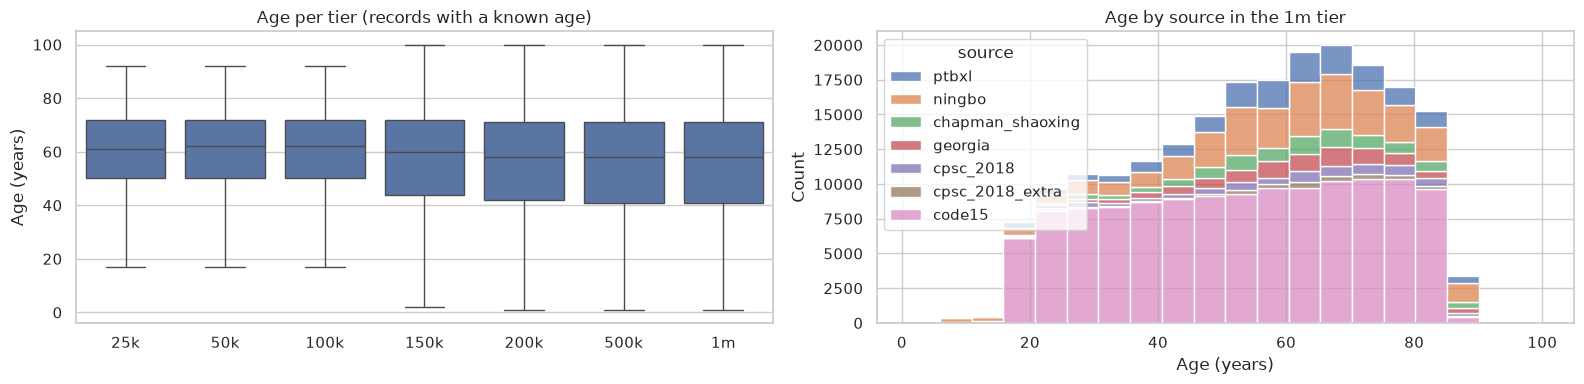

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
ages = pd.concat([rows[["age"]].assign(tier=name) for name, rows in tiers.items()], ignore_index=True)
sns.boxplot(ages.dropna(), x="tier", y="age", showfliers=False, ax=axes[0])
axes[0].set(title="Age per tier (records with a known age)", xlabel="", ylabel="Age (years)")
sample = tiers[list(tiers)[-1]].dropna(subset=["age"])
sns.histplot(sample, x="age", hue="source", binwidth=5, multiple="stack", ax=axes[1])
axes[1].set(title=f"Age by source in the {list(tiers)[-1]} tier", xlabel="Age (years)")
plt.tight_layout()
plt.show()

**Finding: larger tiers are younger, more often female, and much less often labeled.**

- **Age:** known for 99% of records up to 50k. The share falls as MIMIC enters, because the local MIMIC tables
  have no age: 80% at 100k, 90% at 200k, 41% at 500k and 21% at 1M.
  - The median known age is 61-62 up to 100k and 58-60 from 150k, as CODE-15 is younger.
- **Sex:** the male share of records with a known sex is 53-55% up to 100k and 46-50% from 150k, as CODE-15 is
  60% female.
- **Labels:** a source label is available for 79% of the 25k tier, 53% of 100k, 27% of 200k and 5% of 1M.
  - The PTB-XL label files are the same in every tier.
  - Ningbo and Chapman have a defined mapped label for only half of their records.
- **Review flags:** 0.1-0.6% of records up to 200k carry one, because flagged records come last within each
  source. At 500k the share is 10%: every local MIMIC record, including the 23,007 flagged ones, is in that
  tier.
- **Patients:** IDs exist only for PTB-XL, MIMIC and CODE-15.
  - The 25k and 50k tiers hold 15,015 PTB-XL patients plus 7,595 and 32,595 Challenge records without an ID.
  - The 19,625 MIMIC records of the 100k tier come from 11,900 patients.
  - Known patients reach 102,406 at 200k and 265,848 at 1M.

## 5. Checks

In [9]:
hashes, heldout_ids, heldout_patients = heldout_references()
names = list(tiers)
manifests = {name: pd.read_csv(ROOT / f"data/processed/clean_{name}_v2/train_manifest.csv", dtype=str,
                               usecols=["record_id"])["record_id"] for name in names}


def checks(name: str, larger: str | None) -> pd.Series:
    """
    Check one tier against its manifest, the next tier and the exclusion rules.

    Parameters
    ----------
    name : str
        Tier name.
    larger : str | None
        Name of the next larger tier, or None for the largest.

    Returns
    -------
    pd.Series
        One result per check.
    """
    rows = tiers[name]
    hashed = rows.loc[rows["signal_sha256"] != "", "signal_sha256"]
    heldout = rows["record_id"].isin(heldout_ids) | rows["patient_id"].isin(heldout_patients)
    return pd.Series({
        "manifest equals the first N candidates": manifests[name].tolist() == rows["record_id"].tolist(),
        "contained in the next tier": larger is None or set(manifests[name]) <= set(manifests[larger]),
        "PTB-XL held-out records or patients": int(heldout.sum()),
        "copies of a PTB-XL record from another source": int(
            ((rows["source"] != "ptbxl") & rows["signal_sha256"].isin(hashes)).sum()),
        "repeated waveform hashes": int(hashed.duplicated().sum()),
        "SPH records": int((rows["source"] == "sph").sum()),
    })


display(pd.DataFrame({name: checks(name, larger)
                      for name, larger in zip(names, [*names[1:], None], strict=True)}).T)
labels = pd.read_csv(ROOT / "data/processed/clean_25k_v2/labels_fraction1.csv", dtype=str)
limited = pd.read_csv(ROOT / "data/processed/clean_25k_v2/labels_fraction0.1.csv", dtype=str)
print(f"PTB-XL labels in every tier: {len(labels):,} (full budget), {len(limited):,} (limited budget)")

,manifest equals the first N candidates,contained in the next tier,PTB-XL held-out records or patients,copies of a PTB-XL record from another source,repeated waveform hashes,SPH records
25k,True,True,0,0,0,0
50k,True,True,0,0,0,0
100k,True,True,0,0,0,0
150k,True,True,0,0,0,0
200k,True,True,0,0,0,0
500k,True,True,0,0,0,0
1m,True,True,0,0,0,0


PTB-XL labels in every tier: 15,349 (full budget), 1,517 (limited budget)


**Finding: every check passes.**

- Each tier manifest is exactly the first N candidates of the saved order and is contained in the next tier.
- No tier holds a PTB-XL development, calibration or test record or patient, a copy of any PTB-XL record from
  another source, a repeated waveform, or an SPH record.
- Every tier carries the same 15,349 full-budget and 1,517 limited-budget PTB-XL labels.

## 6. Conclusions

- **Sources.** The curated human-read sources give 80,375 clean records, not enough for 100k. The 25k and 50k
  tiers are curated only, and 100k adds 19,625 MIMIC records.
- **CODE-15.** 127,268 cleaned ten-second exams enter from 150k on. Their stored amplitudes are about 1.6-2
  times millivolts, so the unit remains unresolved; the policy was applied at both plausible scales.
- **Large tiers.** 500k and 1M depend on MIMIC records that are not downloaded yet: 19% and 60% of their rows
  are pending. At the observed failure rate, 1M is expected to be about 6,400 records short once they are
  scored.
- **Composition drifts.** Larger tiers are younger, more female, less often labeled and more often without an
  age. A data-scaling comparison across tiers therefore changes the population as well as the amount of data.